In [1]:
import numpy as np
import pickle
import pandas as pd
import datetime, time
import math
import matplotlib.pyplot as plt

**Understanding the dataset**

In [2]:
# df = pd.read_csv(f"BTCUSDT-15m-data.csv")
df = pd.read_csv(fr"C:\Users\toanl\OneDrive\Documents\new_exp\all_data\SOLUSDT-5m-TEST-NEW-6M.csv")

print(df.head())

   Unnamed: 0                  timestamp      open_time    open    high  \
0           0  2025-05-10 00:00:00+00:00  1746835200000  172.77  173.49   
1           1  2025-05-10 00:05:00+00:00  1746835500000  173.48  174.30   
2           2  2025-05-10 00:10:00+00:00  1746835800000  174.23  174.50   
3           3  2025-05-10 00:15:00+00:00  1746836100000  174.18  175.19   
4           4  2025-05-10 00:20:00+00:00  1746836400000  175.07  175.09   

      low   close     volume     close_time      quote_av  trades  tb_base_av  \
0  172.77  173.48   8428.816  1746835499999  1.459034e+06    6893    5770.765   
1  173.43  174.24  18481.662  1746835799999  3.213669e+06   10528   13670.991   
2  173.82  174.18  14455.558  1746836099999  2.518733e+06   11068    6278.249   
3  174.13  175.07  30921.033  1746836399999  5.406251e+06   16863   24860.965   
4  173.89  173.96  29270.321  1746836699999  5.105100e+06   21736   13333.813   

    tb_quote_av  ignore  
0  9.990692e+05       0  
1  2.37720

**Visualize data**

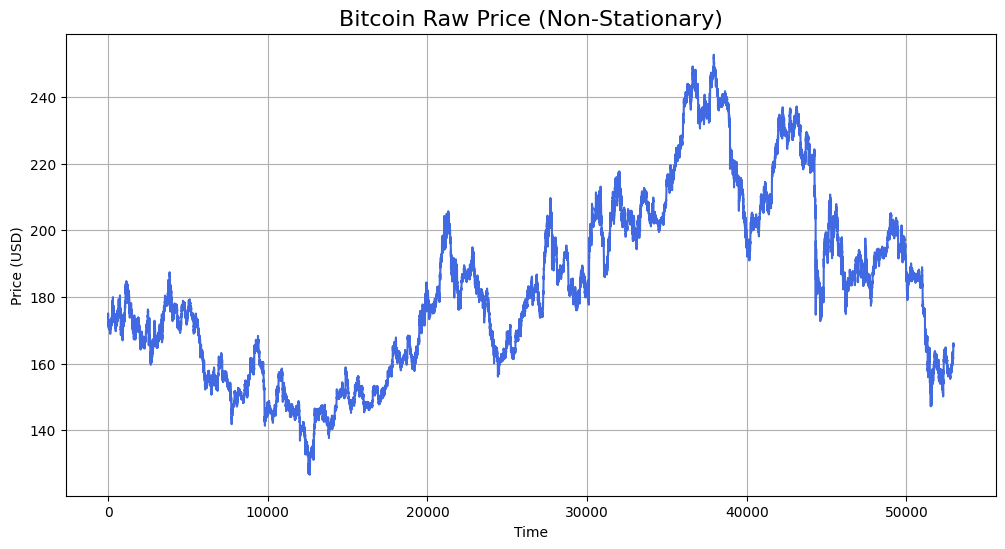

In [3]:
prices = df['close']

plt.figure(figsize=(12, 6))
plt.plot(prices, color='royalblue')
plt.title('Bitcoin Raw Price (Non-Stationary)', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.grid()
plt.show()

**Visualize how mean changes over time**

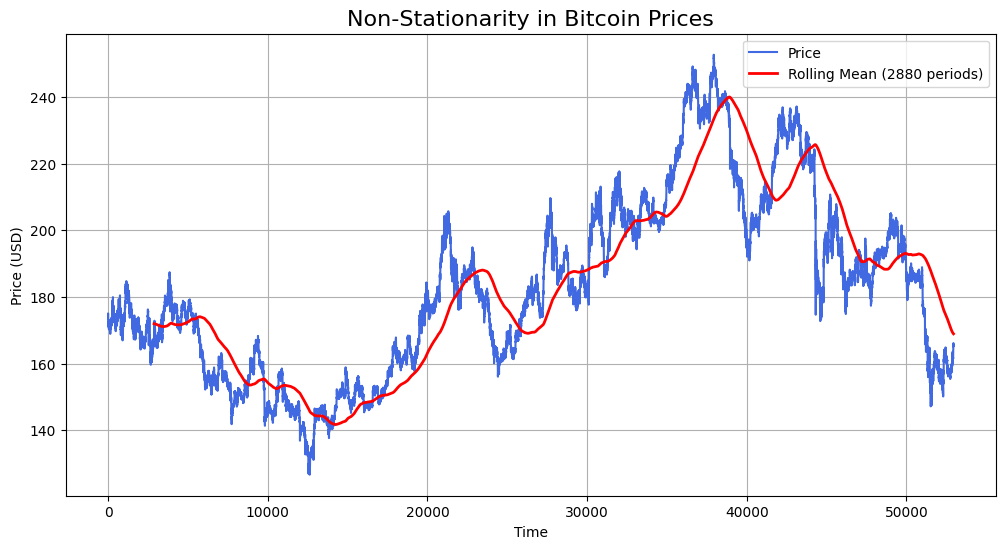

In [4]:
window = 96 * 30

moving_averages = []

for i in range(len(prices)):
    if i < window - 1:
        moving_averages.append(np.nan)
    else:
        window_data = prices[i - window + 1:i + 1]
        mean = np.mean(window_data)
        moving_averages.append(mean)

plt.figure(figsize=(12, 6))
plt.plot(prices, color='royalblue', label='Price')
plt.plot(moving_averages, color='red', linewidth=2, label=f'Rolling Mean ({window} periods)')
plt.title('Non-Stationarity in Bitcoin Prices', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()


**Visualize how variance changes over time**

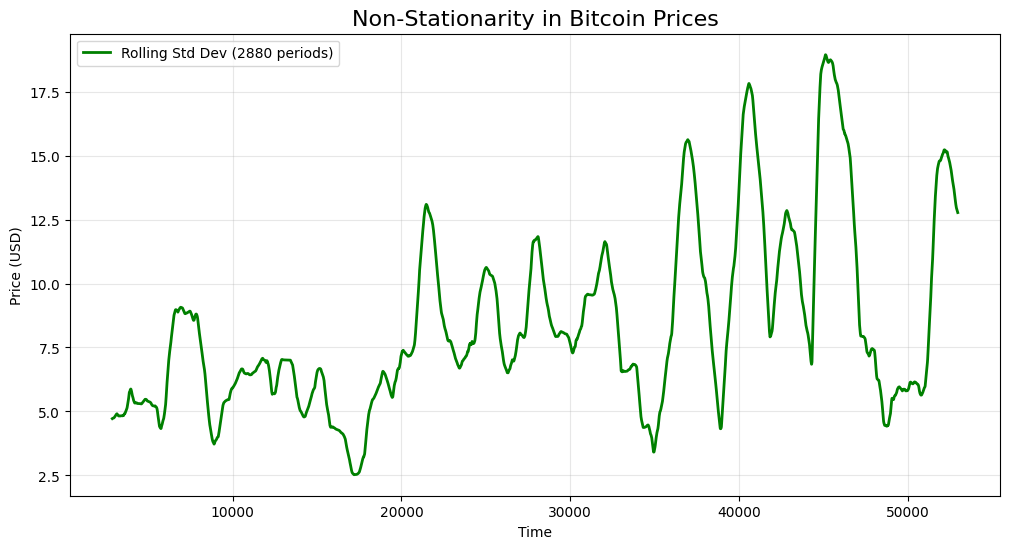

In [5]:
window = 96 * 30

moving_std = []

for i in range(len(prices)):
    if i < window - 1:
        moving_std.append(np.nan)
    else:
        window_data = prices[i - window + 1:i + 1]
        std = np.std(window_data, ddof=1)
        moving_std.append(std)

plt.figure(figsize=(12, 6))
plt.plot(moving_std, color='green', linewidth=2, label=f'Rolling Std Dev ({window} periods)')
plt.title('Non-Stationarity in Bitcoin Prices', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Stationary transformation**

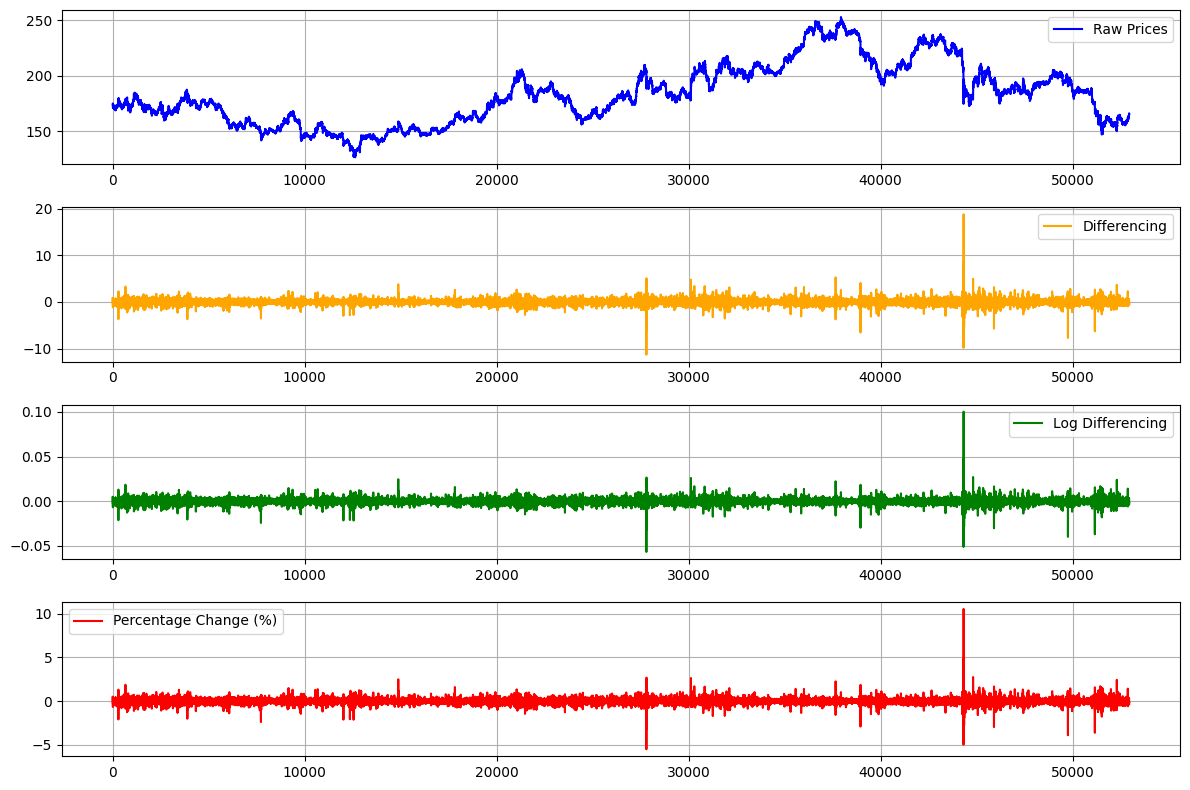

In [8]:
# Differencing
diff_prices = [np.nan]
for i in range(1, len(prices)):
    diff_prices.append(prices[i] - prices[i-1])

# -----------------------------
# Approach 1: Log Differencing
# -----------------------------
log_prices = np.log(prices)
log_diff_prices = [np.nan]
for i in range(1, len(log_prices)):
    log_diff_prices.append(log_prices[i] - log_prices[i-1])

# -----------------------------
# Approach 2: Percentage Change
# -----------------------------
pct_change_prices = [np.nan]
for i in range(1, len(prices)):
    pct_change_prices.append(((prices[i] - prices[i-1]) / prices[i-1]) * 100)

# -----------------------------
# Plot all
# -----------------------------
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(prices, label="Raw Prices", color="blue")
plt.legend()
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(diff_prices, label="Differencing", color="orange")
plt.legend()
plt.grid()

plt.subplot(4, 1, 3)
plt.plot(log_diff_prices, label="Log Differencing", color="green")
plt.legend()
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(pct_change_prices, label="Percentage Change (%)", color="red")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()